# Video Game Data Pipeline
# DSC 540 Data Preparation
# Kevin Danh

## Milestone 2

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Load the dataset
df = pd.read_csv("preprocessed_video_games.csv")
df.head(10)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,Tetris,GB,1989,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,New Super Mario Bros.,DS,2006,Platform,Nintendo,11.28,9.14,6.50,2.88,29.80
7,Wii Play,Wii,2006,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92
8,New Super Mario Bros. Wii,Wii,2009,Platform,Nintendo,14.44,6.94,4.70,2.24,28.32
9,Duck Hunt,NES,1984,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


In [3]:
# Step 1: Replace headers
# This ensure that the headers are consistent and readable.
df.rename(columns={
    'Year_of_Release': 'Year', 
    'NA_Sales': 'NorthAmerica_Sales',
    'EU_Sales': 'Europe_Sales',
    'JP_Sales': 'Japan_Sales',
    'Other_Sales': 'Other_Sales',
    'Global_Sales': 'Global_Sales'
}, inplace=True)

df.head(10)

,Name,Platform,Year,Genre,Publisher,NorthAmerica_Sales,Europe_Sales,Japan_Sales,Other_Sales,Global_Sales
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,Tetris,GB,1989,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,New Super Mario Bros.,DS,2006,Platform,Nintendo,11.28,9.14,6.50,2.88,29.80
7,Wii Play,Wii,2006,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92
8,New Super Mario Bros. Wii,Wii,2009,Platform,Nintendo,14.44,6.94,4.70,2.24,28.32
9,Duck Hunt,NES,1984,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


In [4]:
# Checking the number of rows and columns
df.shape

(16416, 10)

In [5]:
# Checking for missing values
nan_counts = df.isna().sum()
nan_counts

Name                  0
Platform              0
Year                  0
Genre                 0
Publisher             0
NorthAmerica_Sales    0
Europe_Sales          0
Japan_Sales           0
Other_Sales           0
Global_Sales          0
dtype: int64

In [6]:
for col in df.columns:
    print(f"{col} - {df[col].nunique()} unique values")

Name - 11397 unique values
Platform - 31 unique values
Year - 39 unique values
Genre - 12 unique values
Publisher - 579 unique values
NorthAmerica_Sales - 401 unique values
Europe_Sales - 307 unique values
Japan_Sales - 244 unique values
Other_Sales - 155 unique values
Global_Sales - 628 unique values


In [7]:
# Count of unique values for Genre
print("Genre counts:")
print(df['Genre'].value_counts())

# Count of unique values for Platform
print("\nPlatform counts:")
print(df['Platform'].value_counts())

Genre counts:
Genre
Action          3307
Sports          2306
Misc            1697
Role-Playing    1483
Shooter         1296
Adventure       1291
Racing          1225
Platform         878
Simulation       855
Fighting         837
Strategy         672
Puzzle           569
Name: count, dtype: int64

Platform counts:
Platform
PS2     2127
DS      2122
PS3     1306
Wii     1286
X360    1232
PSP     1193
PS      1190
PC       952
XB       803
GBA      786
GC       542
3DS      512
PSV      429
PS4      393
N64      316
XOne     247
SNES     239
SAT      173
WiiU     147
2600     116
NES       98
GB        97
DC        52
GEN       27
NG        12
SCD        6
WS         6
3DO        3
TG16       2
GG         1
PCFX       1
Name: count, dtype: int64


In [8]:
# Step 2: Fix casing / inconsistent values
# This will standardize 'Genre' and 'Platform' to title case and capitalize all respectively.
df['Genre'] = df['Genre'].str.title()
df['Platform'] = df['Platform'].str.upper()
df.head(10)

,Name,Platform,Year,Genre,Publisher,NorthAmerica_Sales,Europe_Sales,Japan_Sales,Other_Sales,Global_Sales
0,Wii Sports,WII,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,Mario Kart Wii,WII,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52
3,Wii Sports Resort,WII,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,Tetris,GB,1989,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,New Super Mario Bros.,DS,2006,Platform,Nintendo,11.28,9.14,6.50,2.88,29.80
7,Wii Play,WII,2006,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92
8,New Super Mario Bros. Wii,WII,2009,Platform,Nintendo,14.44,6.94,4.70,2.24,28.32
9,Duck Hunt,NES,1984,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


In [9]:
# Step 3: Removing platforms that are not recognizable or does not contain a lot of meaningful data
# This will remove platforms shown from value_counts that do not make a meaningful impact of the analysis and are possible outliers.
# List of recognized platforms to keep
recognized_platforms = [
    'PS2','DS','PS3','WII','X360','PSP','PS','PC','XB','GBA','GC',
    '3DS','PSV','PS4','N64','XONE','SNES','SAT','WIIU','2600','NES','GB','DC','GEN','NG'
]

# Filter the dataframe
df = df[df['Platform'].isin(recognized_platforms)]
df.shape

(16397, 10)

In [10]:
# Step 4: Identify outliers in Global_Sales
# This will remove extreme outliers using IQR method.
Q1 = df['Global_Sales'].quantile(0.25)
Q3 = df['Global_Sales'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df_cleaned = df[(df['Global_Sales'] >= lower) & (df['Global_Sales'] <= upper)].copy()
df_cleaned.head(10)

,Name,Platform,Year,Genre,Publisher,NorthAmerica_Sales,Europe_Sales,Japan_Sales,Other_Sales,Global_Sales
1870,NASCAR Thunder 2004,PS2,2003,Racing,Electronic Arts,0.53,0.41,0.00,0.14,1.08
1871,SpongeBob SquarePants: Revenge of the Flying D...,PS2,2002,Platform,THQ,0.53,0.41,0.00,0.14,1.08
1872,Imagine: Babysitters,DS,2008,Simulation,Ubisoft,0.63,0.35,0.00,0.10,1.08
1873,Namco Museum Battle Collection,PSP,2005,Misc,Sony Computer Entertainment,0.75,0.18,0.00,0.16,1.08
1874,Fisherman's Bass Club,PS2,2002,Sports,Agetec,0.53,0.41,0.00,0.14,1.08
1875,Empire: Total War,PC,2009,Strategy,Sega,0.01,0.97,0.00,0.10,1.08
1876,Virtua Fighter 5,PS3,2007,Fighting,Sega,0.29,0.51,0.08,0.20,1.08
1877,Dante's Inferno,PS3,2010,Action,Electronic Arts,0.64,0.28,0.04,0.13,1.08
1878,Toy Story 3: The Video Game,PS3,2010,Action,Disney Interactive Studios,0.51,0.40,0.00,0.16,1.08
1879,Joust,2600,1982,Platform,Atari,1.01,0.06,0.00,0.01,1.08


In [11]:
df_cleaned.shape

(14528, 10)

In [12]:
# Check on games with the same name on multiple platforms
duplicate_names = df.groupby('Name')['Platform'].nunique()
duplicate_games = duplicate_names[duplicate_names > 1]

duplicate_games

Name
 Frozen: Olaf's Quest               2
007: Quantum of Solace              6
007: The World is not Enough        2
11eyes: CrossOver                   2
18 Wheeler: American Pro Trucker    2
                                   ..
iCarly                              2
iCarly 2: iJoin The Click!          2
nail'd                              2
pro evolution soccer 2011           6
uDraw Studio: Instant Artist        2
Name: Platform, Length: 2748, dtype: int64

In [13]:
# Step 5: Make a new column depicting which game has been released on multiple platforms
# This new column will tell me which duplicated entry is actually a game collected that has been released on a different platform.
# Count how many platforms each game appears on
platform_counts = df_cleaned.groupby('Name')['Platform'].transform('nunique')

# Create a boolean column: True if game has multiple platforms, False otherwise
df_cleaned['Multi_Platform'] = platform_counts > 1

df_cleaned[['Name', 'Platform', 'Multi_Platform']].head(10)

,Name,Platform,Multi_Platform
1870,NASCAR Thunder 2004,PS2,True
1871,SpongeBob SquarePants: Revenge of the Flying D...,PS2,True
1872,Imagine: Babysitters,DS,False
1873,Namco Museum Battle Collection,PSP,False
1874,Fisherman's Bass Club,PS2,False
1875,Empire: Total War,PC,False
1876,Virtua Fighter 5,PS3,False
1877,Dante's Inferno,PS3,True
1878,Toy Story 3: The Video Game,PS3,True
1879,Joust,2600,False


In [49]:
# Create human readable dataset after all transformations
df_cleaned.to_csv('cleaned_videogames.csv', index=False)
display(df_cleaned.head(10))
display(df_cleaned.tail(10))

,Name,Platform,Year,Genre,Publisher,NorthAmerica_Sales,Europe_Sales,Japan_Sales,Other_Sales,Global_Sales,Multi_Platform
1870,NASCAR Thunder 2004,PS2,2003,Racing,Electronic Arts,0.53,0.41,0.00,0.14,1.08,True
1871,SpongeBob SquarePants: Revenge of the Flying D...,PS2,2002,Platform,THQ,0.53,0.41,0.00,0.14,1.08,True
1872,Imagine: Babysitters,DS,2008,Simulation,Ubisoft,0.63,0.35,0.00,0.10,1.08,False
1873,Namco Museum Battle Collection,PSP,2005,Misc,Sony Computer Entertainment,0.75,0.18,0.00,0.16,1.08,False
1874,Fisherman's Bass Club,PS2,2002,Sports,Agetec,0.53,0.41,0.00,0.14,1.08,False
1875,Empire: Total War,PC,2009,Strategy,Sega,0.01,0.97,0.00,0.10,1.08,False
1876,Virtua Fighter 5,PS3,2007,Fighting,Sega,0.29,0.51,0.08,0.20,1.08,False
1877,Dante's Inferno,PS3,2010,Action,Electronic Arts,0.64,0.28,0.04,0.13,1.08,True
1878,Toy Story 3: The Video Game,PS3,2010,Action,Disney Interactive Studios,0.51,0.40,0.00,0.16,1.08,True
1879,Joust,2600,1982,Platform,Atari,1.01,0.06,0.00,0.01,1.08,False


,Name,Platform,Year,Genre,Publisher,NorthAmerica_Sales,Europe_Sales,Japan_Sales,Other_Sales,Global_Sales,Multi_Platform
16406,15 Days,PC,2009,Adventure,DTP Entertainment,0.00,0.01,0.00,0.0,0.01,False
16407,Men in Black II: Alien Escape,GC,2003,Shooter,Infogrames,0.01,0.00,0.00,0.0,0.01,True
16408,Aiyoku no Eustia,PSV,2014,Misc,dramatic create,0.00,0.00,0.01,0.0,0.01,False
16409,Woody Woodpecker in Crazy Castle 5,GBA,2002,Platform,Kemco,0.01,0.00,0.00,0.0,0.01,False
16410,SCORE International Baja 1000: The Official Game,PS2,2008,Racing,Activision,0.00,0.00,0.00,0.0,0.01,True
16411,Samurai Warriors: Sanada Maru,PS3,2016,Action,Tecmo Koei,0.00,0.00,0.01,0.0,0.01,True
16412,LMA Manager 2007,X360,2006,Sports,Codemasters,0.00,0.01,0.00,0.0,0.01,False
16413,Haitaka no Psychedelica,PSV,2016,Adventure,Idea Factory,0.00,0.00,0.01,0.0,0.01,False
16414,Spirits & Spells,GBA,2003,Platform,Wanadoo,0.01,0.00,0.00,0.0,0.01,True
16415,Winning Post 8 2016,PSV,2016,Simulation,Tecmo Koei,0.00,0.00,0.01,0.0,0.01,True


In this project, the data wrangling steps included replacing headers for clarity, removing unrecognizable platforms, fixing inconsistent values and casing, identifying outliers in Global_Sales, and creating a boolean column to indicate multi-platform releases. While the dataset is publicly available video game sales data, there are no strict legal or regulatory guidelines directly governing its use, though care must be taken to ensure proper attribution of sources if published. The transformations could introduce bias if, for example, rare platforms were removed or if outliers were excluded, potentially affecting conclusions about sales trends or platform popularity. Assumptions made during cleaning included treating each game-platform combination as unique and assuming multi-platform releases should be flagged for analysis. The data was sourced Kaggle datasets, verified for consistency against published sales records, and acquired ethically as open-source content. To mitigate ethical implications, all transformations were documented clearly, unusual or rare platforms were either flagged or excluded transparently, and analyses are performed with awareness of potential biases introduced by cleaning decisions, ensuring transparency and reproducibility of results.

## Milestone 3

In [15]:
from bs4 import BeautifulSoup

In [16]:
with open("List of Game of the Year awards - Wikipedia.html", 'r', encoding = "utf-8") as fd:
    soup = BeautifulSoup(fd)
    fd.close()

In [17]:
# Finding all tables using the specified class that contains the data for this project
tables = soup.find_all("table", {"class": "wikitable"})
tables[1]

<table class="wikitable">
<tbody><tr>
<th>Year</th>
<th>Game</th>
<th>Genre</th>
<th>Developer(s)
</th></tr>
<tr>
<td>2010</td>
<td><i><a href="https://en.wikipedia.org/wiki/Mafia_II" title="Mafia II">Mafia II</a></i><sup class="reference" id="cite_ref-34"><a href="https://en.wikipedia.org/wiki/List_of_Game_of_the_Year_awards#cite_note-34"><span class="cite-bracket">[</span>34<span class="cite-bracket">]</span></a></sup></td>
<td><a href="https://en.wikipedia.org/wiki/Action-adventure_game" title="Action-adventure game">Action-adventure game</a></td>
<td><a href="https://en.wikipedia.org/wiki/2K_Czech" title="2K Czech">2K Czech</a>
</td></tr>
<tr>
<td>2011</td>
<td><i>Family Farm</i></td>
<td><a href="https://en.wikipedia.org/wiki/Strategy_video_game" title="Strategy video game">Strategy video game</a></td>
<td>Hammerware
</td></tr>
<tr>
<td rowspan="2">2012</td>
<td><i><a href="https://en.wikipedia.org/wiki/Dead_Trigger" title="Dead Trigger">Dead Trigger</a></i></td>
<td><a href="http

In [18]:
# Extracting each table and converting to a big dataframe
dfs = []

for table in tables:
    # Extract headers
    headers = [th.get_text(strip=True) for th in table.find_all("th")]

    # Extract rows
    rows = []
    for tr in table.find_all("tr")[1:]:
        cells = [td.get_text(strip=True) for td in tr.find_all("td")]
        if cells:
            rows.append(cells)

    # Convert to DataFrame
    df_table = pd.DataFrame(rows, columns=headers)
    dfs.append(df_table)

# Combine all tables into a single DataFrame
wiki_all = pd.concat(dfs, ignore_index=True)

wiki_all.head()

,Year,Game,Genre,Developer(s),Arcade,Standalone,Console,Computer,Title,Developer,Ref
0,1998,GoldenEye 007[1],First-person shooter,Rare,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1999,The Legend of Zelda: Ocarina of Time[2],Action-adventure,Nintendo EAD,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2000,Console:MediEvil 2[3],Action-adventure,SCE Studio Cambridge,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Handheld:Pokémon Yellow[4],Role-playing,Game Freak,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,PC:Deus Ex[5],Action role-playing,Ion Storm,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
# Shifting the rows that contain a non-numerical value in years to the right
# This would fix the issue that happened when grabbing the data from specific wiki tables with multiple games that won awards in one year
def shift_year(row):
    # Convert row to list
    row_list = row.tolist()
    
    try:
        # Check if the first column is a valid year
        val = int(row_list[0])
        if 1900 <= val <= 2100:
            return row_list  # already correct
        else:
            raise ValueError
    except:
        # Not a year: shift everything right, insert None at first position
        return [None] + row_list[:-1]

# Apply row-wise
wiki_fixed = wiki_all.apply(shift_year, axis=1, result_type='expand')

# Optional: restore original column names
wiki_fixed.columns = wiki_all.columns

wiki_fixed.head(10)

,Year,Game,Genre,Developer(s),Arcade,Standalone,Console,Computer,Title,Developer,Ref
0,1998,GoldenEye 007[1],First-person shooter,Rare,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1999,The Legend of Zelda: Ocarina of Time[2],Action-adventure,Nintendo EAD,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2000,Console:MediEvil 2[3],Action-adventure,SCE Studio Cambridge,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,None,Handheld:Pokémon Yellow[4],Role-playing,Game Freak,None,NaN,NaN,NaN,NaN,NaN,NaN
4,None,PC:Deus Ex[5],Action role-playing,Ion Storm,None,NaN,NaN,NaN,NaN,NaN,NaN
5,2001,Console:Gran Turismo 3: A-Spec[6],Racing,Polyphony Digital,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,None,Handheld:Tony Hawk's Pro Skater 2[7],Sports,Vicarious Visions,None,NaN,NaN,NaN,NaN,NaN,NaN
7,None,PC:Max Payne[8],Third-person shooter,Remedy Entertainment,None,NaN,NaN,NaN,NaN,NaN,NaN
8,2002,Console:Halo: Combat Evolved[9],First-person shooter,Bungie,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,None,Handheld:SMS Chess[10],,Purple Software,None,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
# Forward filling all the missing values from the year column
# This fix should resemble multiple games that won awards in the same year
wiki_fixed["Year"] = wiki_fixed["Year"].ffill()

wiki_fixed.head(10)

,Year,Game,Genre,Developer(s),Arcade,Standalone,Console,Computer,Title,Developer,Ref
0,1998,GoldenEye 007[1],First-person shooter,Rare,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1999,The Legend of Zelda: Ocarina of Time[2],Action-adventure,Nintendo EAD,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2000,Console:MediEvil 2[3],Action-adventure,SCE Studio Cambridge,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2000,Handheld:Pokémon Yellow[4],Role-playing,Game Freak,None,NaN,NaN,NaN,NaN,NaN,NaN
4,2000,PC:Deus Ex[5],Action role-playing,Ion Storm,None,NaN,NaN,NaN,NaN,NaN,NaN
5,2001,Console:Gran Turismo 3: A-Spec[6],Racing,Polyphony Digital,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2001,Handheld:Tony Hawk's Pro Skater 2[7],Sports,Vicarious Visions,None,NaN,NaN,NaN,NaN,NaN,NaN
7,2001,PC:Max Payne[8],Third-person shooter,Remedy Entertainment,None,NaN,NaN,NaN,NaN,NaN,NaN
8,2002,Console:Halo: Combat Evolved[9],First-person shooter,Bungie,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2002,Handheld:SMS Chess[10],,Purple Software,None,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
import re

# Replacing the subscripts that were entered as they were found in the tables as a reference mark
wiki_fixed["Game"] = wiki_fixed["Game"].str.replace(r'\[\d+\]', '', regex=True)

# Stripping any leading/trailing whitespace
wiki_fixed["Game"] = wiki_fixed["Game"].str.strip()

wiki_fixed

,Year,Game,Genre,Developer(s),Arcade,Standalone,Console,Computer,Title,Developer,Ref
0,1998,GoldenEye 007,First-person shooter,Rare,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1999,The Legend of Zelda: Ocarina of Time,Action-adventure,Nintendo EAD,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2000,Console:MediEvil 2,Action-adventure,SCE Studio Cambridge,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2000,Handheld:Pokémon Yellow,Role-playing,Game Freak,None,NaN,NaN,NaN,NaN,NaN,NaN
4,2000,PC:Deus Ex,Action role-playing,Ion Storm,None,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
695,2012,The Walking Dead,Graphic adventure,Telltale Games,NaN,NaN,NaN,NaN,NaN,NaN,NaN
696,2013,The Last of Us,Action-adventure,Naughty Dog,NaN,NaN,NaN,NaN,NaN,NaN,NaN
697,2014,Dragon Age: Inquisition,Action role-playing,BioWare,NaN,NaN,NaN,NaN,NaN,NaN,NaN
698,2015,The Witcher 3: Wild Hunt,Action role-playing,CD Projekt Red,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
# Counting occurrences of each game title
# Certain games won awards from different events and are entered in as a possible duplicate
reward_counts = wiki_fixed["Game"].value_counts()

# Mapping the counts back to a new column in the DataFrame
wiki_fixed["Award_Count"] = wiki_fixed["Game"].map(reward_counts)

# Checking games that won multiple rewards
multiple_awards = wiki_fixed[wiki_fixed["Award_Count"] > 1]

multiple_awards[["Game", "Award_Count"]].drop_duplicates()

,Game,Award_Count
0,GoldenEye 007,3.0
1,The Legend of Zelda: Ocarina of Time,6.0
11,Call of Duty,2.0
12,Half-Life 2,6.0
14,BioShock,6.0
...,...,...
589,Alan Wake 2,3.0
628,Alien: Isolation,2.0
630,Dishonored 2,2.0
633,Disco Elysium,2.0


In [23]:
# Checking out the configured dataframe
multiple_awards

,Year,Game,Genre,Developer(s),Arcade,Standalone,Console,Computer,Title,Developer,Ref,Award_Count
0,1998,GoldenEye 007,First-person shooter,Rare,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0
1,1999,The Legend of Zelda: Ocarina of Time,Action-adventure,Nintendo EAD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0
11,2003,Call of Duty,First-person shooter,Infinity Ward,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
12,2004,Half-Life 2,First-person shooter,Valve,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0
14,2007,BioShock,First-person shooter,Irrational Games,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...
695,2012,The Walking Dead,Graphic adventure,Telltale Games,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0
696,2013,The Last of Us,Action-adventure,Naughty Dog,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0
697,2014,Dragon Age: Inquisition,Action role-playing,BioWare,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0
698,2015,The Witcher 3: Wild Hunt,Action role-playing,CD Projekt Red,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0


In [24]:
# Resetting the index of the dataframe after the duplicates were dropped
multiple_awards.reset_index(drop=True, inplace=True)
multiple_awards

,Year,Game,Genre,Developer(s),Arcade,Standalone,Console,Computer,Title,Developer,Ref,Award_Count
0,1998,GoldenEye 007,First-person shooter,Rare,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0
1,1999,The Legend of Zelda: Ocarina of Time,Action-adventure,Nintendo EAD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0
2,2003,Call of Duty,First-person shooter,Infinity Ward,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
3,2004,Half-Life 2,First-person shooter,Valve,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0
4,2007,BioShock,First-person shooter,Irrational Games,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...
508,2012,The Walking Dead,Graphic adventure,Telltale Games,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0
509,2013,The Last of Us,Action-adventure,Naughty Dog,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0
510,2014,Dragon Age: Inquisition,Action role-playing,BioWare,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0
511,2015,The Witcher 3: Wild Hunt,Action role-playing,CD Projekt Red,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0


In [25]:
# Checking the columns with NA values
multiple_awards.isna().sum()

Year              0
Game              0
Genre             0
Developer(s)      5
Arcade          513
Standalone      513
Console         513
Computer        513
Title           513
Developer       513
Ref             513
Award_Count       0
dtype: int64

In [26]:
# Dropping columns where all values are NaN
# As those columns were originally pulled from the wiki, these columns do not provide necessary information for my project
final_wiki = multiple_awards.dropna(axis=1, how='all').copy()
final_wiki

,Year,Game,Genre,Developer(s),Award_Count
0,1998,GoldenEye 007,First-person shooter,Rare,3.0
1,1999,The Legend of Zelda: Ocarina of Time,Action-adventure,Nintendo EAD,6.0
2,2003,Call of Duty,First-person shooter,Infinity Ward,2.0
3,2004,Half-Life 2,First-person shooter,Valve,6.0
4,2007,BioShock,First-person shooter,Irrational Games,6.0
...,...,...,...,...,...
508,2012,The Walking Dead,Graphic adventure,Telltale Games,7.0
509,2013,The Last of Us,Action-adventure,Naughty Dog,15.0
510,2014,Dragon Age: Inquisition,Action role-playing,BioWare,10.0
511,2015,The Witcher 3: Wild Hunt,Action role-playing,CD Projekt Red,10.0


In [50]:
# Create human readable dataset after all transformations
final_wiki.to_csv('cleaned_wiki.csv', index=False)
display(final_wiki.head(10))
display(final_wiki.tail(10))

,Year,Game,Genre,Developer(s),Award_Count
0,1998,GoldenEye 007,First-person shooter,Rare,3.0
1,1999,The Legend of Zelda: Ocarina of Time,Action-adventure,Nintendo EAD,6.0
2,2003,Call of Duty,First-person shooter,Infinity Ward,2.0
3,2004,Half-Life 2,First-person shooter,Valve,6.0
4,2007,BioShock,First-person shooter,Irrational Games,6.0
5,2008,Super Mario Galaxy,Platformer,Nintendo EAD,8.0
6,2009,Batman: Arkham Asylum,Action-adventure,Rocksteady Studios,2.0
7,2010,Mass Effect 2,Action role-playing,BioWare,7.0
8,2011,Portal 2,Puzzle-platformer,Valve,8.0
9,2012,Dishonored,Action-adventure,Arkane Studios,4.0


,Year,Game,Genre,Developer(s),Award_Count
503,2007,Super Mario Galaxy,Platformer,Nintendo EAD,8.0
504,2008,Fallout 3,Action role-playing,Bethesda Game Studios,6.0
505,2009,Uncharted 2: Among Thieves,Action-adventure,Naughty Dog,12.0
506,2010,Red Dead Redemption,Action-adventure,Rockstar San Diego,11.0
507,2011,Batman: Arkham City,Action-adventure,Rocksteady Studios,2.0
508,2012,The Walking Dead,Graphic adventure,Telltale Games,7.0
509,2013,The Last of Us,Action-adventure,Naughty Dog,15.0
510,2014,Dragon Age: Inquisition,Action role-playing,BioWare,10.0
511,2015,The Witcher 3: Wild Hunt,Action role-playing,CD Projekt Red,10.0
512,2017,The Legend of Zelda: Breath of the Wild,Action-adventure,Nintendo EPD,24.0


During the data wrangling process:
- misaligned year entries were corrected
- rows with null values were shifted to the right as intended from the wiki
- missing years were forward-filled as they are related to the last known year value
- wiki reference subscripts were removed from titles
- Award_Count column was created for games that won multiple awards.
- NaN-only columns dropped

While there are no specific legal restrictions on using publicly available Wikipedia tables/data, care must be taken to respect copyright and attribution requirements. The transformations I have made could introduce risks such as misrepresenting the number of awards if duplicates are not handled correctly or unintentionally modifying original game titles. Some assumptions were made, such as interpreting repeated titles as multiple awards. The data was sourced from Wikipedia tables, which are community-curated and generally reliable, though verification against official award lists would improve credibility. The dataset was acquired ethically, as Wikipedia content is freely accessible under Creative Commons licenses. To mitigate ethical implications, all transformations were documented clearly, care was taken to preserve original information where possible, and any assumptions were noted, ensuring transparency and reproducibility in analysis.

## Milestone 4

In [1]:
# Import necessary libaries for API access
import urllib.request, urllib.parse, urllib.error
import json

In [2]:
# Load the API key into a variable
with open("api_keys.json") as f:
    key_dict = json.load(f)
    api_key = key_dict["rawg"]

In [29]:
# Assign url and the key with needed queries
url = "https://api.rawg.io/api/games?key="
# Query for finding the top games of 2025 with pages
query = "&dates=2025-01-01,2025-11-16&ordering=-added&page="
page = "1"
page_size = "&page_size=40"

In [30]:
# Connect to API and return a subset of data
request = url + api_key + query + page + page_size
response = urllib.request.urlopen(request)
data = response.read()
json_data = json.loads(data)

In [31]:
# Turn the API data into a dataframe

df = pd.DataFrame([json_data])
df.head()

,count,next,previous,results,user_platforms
0,17193,https://api.rawg.io/api/games?dates=2025-01-01...,None,[{'slug': 'vampire-the-masquerade-bloodlines-2...,False


### Step 1: Format the data correctly and into readable form

In [32]:
# json_normalize flattens nested JSON (lists of dicts or dicts inside dicts).
from pandas import json_normalize

# Normalize just result column which contents all the data that was requested
df = json_normalize(df.loc[0, "results"])
df.head()

,slug,name,playtime,platforms,stores,released,tba,background_image,rating,rating_top,...,added_by_status.beaten,added_by_status.toplay,added_by_status.dropped,added_by_status.playing,esrb_rating.id,esrb_rating.name,esrb_rating.slug,esrb_rating.name_en,esrb_rating.name_ru,community_rating
0,vampire-the-masquerade-bloodlines-2,Vampire: The Masquerade – Bloodlines 2,329,"[{'platform': {'id': 4, 'name': 'PC', 'slug': ...","[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-10-21,False,https://media.rawg.io/media/games/fb5/fb5e0fdb...,3.86,5,...,28,1370,17.0,38.0,NaN,NaN,NaN,NaN,NaN,NaN
1,hollow-knight-silksong,Hollow Knight: Silksong,24,"[{'platform': {'id': 4, 'name': 'PC', 'slug': ...","[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-09-04,False,https://media.rawg.io/media/games/27c/27cd8b7d...,4.29,5,...,93,823,28.0,64.0,NaN,NaN,NaN,NaN,NaN,NaN
2,clair-obscur-expedition-33,Clair Obscur: Expedition 33,47,"[{'platform': {'id': 4, 'name': 'PC', 'slug': ...","[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-04-24,False,https://media.rawg.io/media/games/466/4667f17f...,4.52,5,...,279,214,34.0,66.0,NaN,NaN,NaN,NaN,NaN,NaN
3,hades-ii,Hades II,7,"[{'platform': {'id': 4, 'name': 'PC', 'slug': ...","[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-09-25,False,https://media.rawg.io/media/games/8fd/8fd2e831...,4.38,5,...,47,265,23.0,55.0,NaN,NaN,NaN,NaN,NaN,NaN
4,split-fiction,Split Fiction,5,"[{'platform': {'id': 4, 'name': 'PC', 'slug': ...","[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-03-06,False,https://media.rawg.io/media/games/02a/02ac22b3...,4.43,5,...,176,215,14.0,37.0,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
# Check the amount of rows and columns
df.shape

(40, 41)

### Step 2: Pulling more data contained in pages and formatting

Since I only got 40 rows of data, that means the API is giving me page 1. The count is 16739 which specifics the number of games the API is said to have for top games in 2025.

In [34]:
import time

# Function to get specific amount pages in the API for specific query of top games in 2025
def get_all_data(page, base_df):
    
    request = url + api_key + query + str(page) + page_size

    # Retry logic and try block
    for attempt in range(3):
        try:
            response = urllib.request.urlopen(request)
            data = json.loads(response.read())
            page_df = json_normalize(data["results"])
            return pd.concat([base_df, page_df], ignore_index=True)

        except Exception as e:
            print(f"Error on page {page}, attempt {attempt+1}: {e}")
            time.sleep(1)  # Wait and retry

    print(f"Failed to load page {page} after 3 attempts.")
    return base_df

In [35]:
# Start the timer for this request
start_time = time.time()

# Start with first page of API request
response = urllib.request.urlopen(request)
data = response.read()
json_data = json.loads(data)

# First 40 games
df = json_normalize(json_data["results"]) 

# Loop through remaining pages
for page in range(2, 100):
    df = get_all_data(page, df)
    time.sleep(0.5)   # Avoids 502 errors
    if page == 100:
        print("Successfully pulled 100 pages!")

# Calculate the time it took for this request
end_time = time.time()
elapsed = end_time - start_time

print(f"\nScraping completed in {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")


Scraping completed in 139.23 seconds (2.32 minutes)


In [36]:
# Check the final amount of rows and columns
df.shape

(3960, 42)

In [37]:
# Save the dataframe locally so I don't have to request it again
df.to_csv("rawg_games.csv", index=False)

### Step 3: Remove unnecessary columns that do not help with project's goal

In [110]:
# Load saved dataframe of API data
df = pd.read_csv("rawg_games.csv")

# Temporary show all the columns and values
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
df.head()

,slug,name,playtime,platforms,stores,released,tba,background_image,rating,rating_top,ratings,ratings_count,reviews_text_count,added,metacritic,suggestions_count,updated,id,score,clip,tags,esrb_rating,user_game,reviews_count,saturated_color,dominant_color,short_screenshots,parent_platforms,genres,added_by_status.yet,added_by_status.owned,added_by_status.beaten,added_by_status.toplay,added_by_status.dropped,added_by_status.playing,esrb_rating.id,esrb_rating.name,esrb_rating.slug,esrb_rating.name_en,esrb_rating.name_ru,community_rating,added_by_status
0,vampire-the-masquerade-bloodlines-2,Vampire: The Masquerade – Bloodlines 2,329,"[{'platform': {'id': 4, 'name': 'PC', 'slug': ...","[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-10-21,False,https://media.rawg.io/media/games/fb5/fb5e0fdb...,3.86,5,"[{'id': 5, 'title': 'exceptional', 'count': 15...",330,37,2428,NaN,554,2025-11-23T11:15:10,303576,NaN,NaN,"[{'id': 31, 'name': 'Singleplayer', 'slug': 's...",NaN,NaN,384,0f0f0f,0f0f0f,"[{'id': -1, 'image': 'https://media.rawg.io/me...","[{'platform': {'id': 1, 'name': 'PC', 'slug': ...","[{'id': 4, 'name': 'Action', 'slug': 'action'}...",286.0,689.0,28.0,1370.0,17.0,38.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,hollow-knight-silksong,Hollow Knight: Silksong,24,"[{'platform': {'id': 4, 'name': 'PC', 'slug': ...","[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-09-04,False,https://media.rawg.io/media/games/27c/27cd8b7d...,4.29,5,"[{'id': 5, 'title': 'exceptional', 'count': 11...",178,8,1459,NaN,428,2025-11-23T18:15:50,292844,NaN,NaN,"[{'id': 31, 'name': 'Singleplayer', 'slug': 's...",NaN,NaN,191,0f0f0f,0f0f0f,"[{'id': -1, 'image': 'https://media.rawg.io/me...","[{'platform': {'id': 1, 'name': 'PC', 'slug': ...","[{'id': 51, 'name': 'Indie', 'slug': 'indie'},...",174.0,277.0,93.0,823.0,28.0,64.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,clair-obscur-expedition-33,Clair Obscur: Expedition 33,47,"[{'platform': {'id': 4, 'name': 'PC', 'slug': ...","[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-04-24,False,https://media.rawg.io/media/games/466/4667f17f...,4.52,5,"[{'id': 5, 'title': 'exceptional', 'count': 24...",301,16,842,NaN,311,2025-11-21T10:22:07,983210,NaN,NaN,"[{'id': 31, 'name': 'Singleplayer', 'slug': 's...",NaN,NaN,320,0f0f0f,0f0f0f,"[{'id': -1, 'image': 'https://media.rawg.io/me...","[{'platform': {'id': 1, 'name': 'PC', 'slug': ...","[{'id': 5, 'name': 'RPG', 'slug': 'role-playin...",82.0,167.0,279.0,214.0,34.0,66.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,hades-ii,Hades II,7,"[{'platform': {'id': 4, 'name': 'PC', 'slug': ...","[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-09-25,False,https://media.rawg.io/media/games/8fd/8fd2e831...,4.38,5,"[{'id': 5, 'title': 'exceptional', 'count': 52...",83,1,728,NaN,372,2025-11-23T12:31:33,891238,NaN,NaN,"[{'id': 31, 'name': 'Singleplayer', 'slug': 's...",NaN,NaN,84,0f0f0f,0f0f0f,"[{'id': -1, 'image': 'https://media.rawg.io/me...","[{'platform': {'id': 1, 'name': 'PC', 'slug': ...","[{'id': 51, 'name': 'Indie', 'slug': 'indie'},...",86.0,252.0,47.0,265.0,23.0,55.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,split-fiction,Split Fiction,5,"[{'platform': {'id': 4, 'name': 'PC', 'slug': ...","[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-03-06,False,https://media.rawg.io/media/games/02a/02ac22b3...,4.43,5,"[{'id': 5, 'title': 'exceptional', 'count': 12...",169,4,651,NaN,0,2025-11-22T22:30:24,994603,NaN,NaN,"[{'id': 42417, 'name': 'Экшен', 'slug': 'ekshe...",NaN,NaN,175,0f0f0f,0f0f0f,"[{'id': -1, 'image': 'https://media.rawg.io/me...","[{'platform': {'id': 1, 'name': 'PC', 'slug': ...","[{'id': 3, 'name': 'Adventure', 'slug': 'adven...",68.0,141.0,176.0,215.0,14.0,37.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [111]:
# Get all column names
df.columns

Index(['slug', 'name', 'playtime', 'platforms', 'stores', 'released', 'tba', 'background_image', 'rating', 'rating_top', 'ratings', 'ratings_count', 'reviews_text_count', 'added', 'metacritic', 'suggestions_count', 'updated', 'id', 'score', 'clip', 'tags', 'esrb_rating', 'user_game', 'reviews_count', 'saturated_color', 'dominant_color', 'short_screenshots', 'parent_platforms', 'genres', 'added_by_status.yet', 'added_by_status.owned', 'added_by_status.beaten', 'added_by_status.toplay', 'added_by_status.dropped', 'added_by_status.playing', 'esrb_rating.id', 'esrb_rating.name', 'esrb_rating.slug', 'esrb_rating.name_en', 'esrb_rating.name_ru', 'community_rating', 'added_by_status'], dtype='object')

In [112]:
# Drop unnecessary columns
df.drop(['slug', 'esrb_rating.slug', 'esrb_rating.name_en', 'esrb_rating.name_ru', 'esrb_rating',
         'background_image', 'added', 'tba', 'esrb_rating.name', 'esrb_rating.id', 'added_by_status.owned', 
         'added_by_status.beaten', 'added_by_status.toplay', 'added_by_status.dropped', 'added_by_status.playing',
         'updated', 'id', 'short_screenshots', 'dominant_color', 'saturated_color', 'clip', 'reviews_text_count',
         'playtime', 'added_by_status.yet', 'community_rating'], axis=1, inplace=True)

In [113]:
# Reset the options
pd.reset_option("display.max_columns")
pd.reset_option("display.width")
# Check the dataframe again
df.head()

,name,platforms,stores,released,rating,rating_top,ratings,ratings_count,metacritic,suggestions_count,score,tags,user_game,reviews_count,parent_platforms,genres,added_by_status
0,Vampire: The Masquerade – Bloodlines 2,"[{'platform': {'id': 4, 'name': 'PC', 'slug': ...","[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-10-21,3.86,5,"[{'id': 5, 'title': 'exceptional', 'count': 15...",330,NaN,554,NaN,"[{'id': 31, 'name': 'Singleplayer', 'slug': 's...",NaN,384,"[{'platform': {'id': 1, 'name': 'PC', 'slug': ...","[{'id': 4, 'name': 'Action', 'slug': 'action'}...",NaN
1,Hollow Knight: Silksong,"[{'platform': {'id': 4, 'name': 'PC', 'slug': ...","[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-09-04,4.29,5,"[{'id': 5, 'title': 'exceptional', 'count': 11...",178,NaN,428,NaN,"[{'id': 31, 'name': 'Singleplayer', 'slug': 's...",NaN,191,"[{'platform': {'id': 1, 'name': 'PC', 'slug': ...","[{'id': 51, 'name': 'Indie', 'slug': 'indie'},...",NaN
2,Clair Obscur: Expedition 33,"[{'platform': {'id': 4, 'name': 'PC', 'slug': ...","[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-04-24,4.52,5,"[{'id': 5, 'title': 'exceptional', 'count': 24...",301,NaN,311,NaN,"[{'id': 31, 'name': 'Singleplayer', 'slug': 's...",NaN,320,"[{'platform': {'id': 1, 'name': 'PC', 'slug': ...","[{'id': 5, 'name': 'RPG', 'slug': 'role-playin...",NaN
3,Hades II,"[{'platform': {'id': 4, 'name': 'PC', 'slug': ...","[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-09-25,4.38,5,"[{'id': 5, 'title': 'exceptional', 'count': 52...",83,NaN,372,NaN,"[{'id': 31, 'name': 'Singleplayer', 'slug': 's...",NaN,84,"[{'platform': {'id': 1, 'name': 'PC', 'slug': ...","[{'id': 51, 'name': 'Indie', 'slug': 'indie'},...",NaN
4,Split Fiction,"[{'platform': {'id': 4, 'name': 'PC', 'slug': ...","[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-03-06,4.43,5,"[{'id': 5, 'title': 'exceptional', 'count': 12...",169,NaN,0,NaN,"[{'id': 42417, 'name': 'Экшен', 'slug': 'ekshe...",NaN,175,"[{'platform': {'id': 1, 'name': 'PC', 'slug': ...","[{'id': 3, 'name': 'Adventure', 'slug': 'adven...",NaN


### Step 4: Handle columns or rows that are be missing a lot of values or provide no information

In [114]:
# Check NA values
df.isna().count()

name                 3960
platforms            3960
stores               3960
released             3960
rating               3960
rating_top           3960
ratings              3960
ratings_count        3960
metacritic           3960
suggestions_count    3960
score                3960
tags                 3960
user_game            3960
reviews_count        3960
parent_platforms     3960
genres               3960
added_by_status      3960
dtype: int64

In [115]:
# Check unique values
df.nunique()

name                 3960
platforms              43
stores                 27
released              310
rating                 87
rating_top              5
ratings               198
ratings_count          49
metacritic              0
suggestions_count     544
score                   0
tags                 3860
user_game               0
reviews_count          52
parent_platforms       30
genres                307
added_by_status         0
dtype: int64

In [116]:
# Remove the columns that contain absolutely no unique values
df.drop(['metacritic', 'score', 'user_game', 'added_by_status'], axis=1, inplace=True)

In [117]:
df.head()

,name,platforms,stores,released,rating,rating_top,ratings,ratings_count,suggestions_count,tags,reviews_count,parent_platforms,genres
0,Vampire: The Masquerade – Bloodlines 2,"[{'platform': {'id': 4, 'name': 'PC', 'slug': ...","[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-10-21,3.86,5,"[{'id': 5, 'title': 'exceptional', 'count': 15...",330,554,"[{'id': 31, 'name': 'Singleplayer', 'slug': 's...",384,"[{'platform': {'id': 1, 'name': 'PC', 'slug': ...","[{'id': 4, 'name': 'Action', 'slug': 'action'}..."
1,Hollow Knight: Silksong,"[{'platform': {'id': 4, 'name': 'PC', 'slug': ...","[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-09-04,4.29,5,"[{'id': 5, 'title': 'exceptional', 'count': 11...",178,428,"[{'id': 31, 'name': 'Singleplayer', 'slug': 's...",191,"[{'platform': {'id': 1, 'name': 'PC', 'slug': ...","[{'id': 51, 'name': 'Indie', 'slug': 'indie'},..."
2,Clair Obscur: Expedition 33,"[{'platform': {'id': 4, 'name': 'PC', 'slug': ...","[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-04-24,4.52,5,"[{'id': 5, 'title': 'exceptional', 'count': 24...",301,311,"[{'id': 31, 'name': 'Singleplayer', 'slug': 's...",320,"[{'platform': {'id': 1, 'name': 'PC', 'slug': ...","[{'id': 5, 'name': 'RPG', 'slug': 'role-playin..."
3,Hades II,"[{'platform': {'id': 4, 'name': 'PC', 'slug': ...","[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-09-25,4.38,5,"[{'id': 5, 'title': 'exceptional', 'count': 52...",83,372,"[{'id': 31, 'name': 'Singleplayer', 'slug': 's...",84,"[{'platform': {'id': 1, 'name': 'PC', 'slug': ...","[{'id': 51, 'name': 'Indie', 'slug': 'indie'},..."
4,Split Fiction,"[{'platform': {'id': 4, 'name': 'PC', 'slug': ...","[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-03-06,4.43,5,"[{'id': 5, 'title': 'exceptional', 'count': 12...",169,0,"[{'id': 42417, 'name': 'Экшен', 'slug': 'ekshe...",175,"[{'platform': {'id': 1, 'name': 'PC', 'slug': ...","[{'id': 3, 'name': 'Adventure', 'slug': 'adven..."


### Step 5: Fix the datatype for "released" column to a datatime object

In [118]:
df['released'] = pd.to_datetime(df['released']).dt.date
df.head()

,name,platforms,stores,released,rating,rating_top,ratings,ratings_count,suggestions_count,tags,reviews_count,parent_platforms,genres
0,Vampire: The Masquerade – Bloodlines 2,"[{'platform': {'id': 4, 'name': 'PC', 'slug': ...","[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-10-21,3.86,5,"[{'id': 5, 'title': 'exceptional', 'count': 15...",330,554,"[{'id': 31, 'name': 'Singleplayer', 'slug': 's...",384,"[{'platform': {'id': 1, 'name': 'PC', 'slug': ...","[{'id': 4, 'name': 'Action', 'slug': 'action'}..."
1,Hollow Knight: Silksong,"[{'platform': {'id': 4, 'name': 'PC', 'slug': ...","[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-09-04,4.29,5,"[{'id': 5, 'title': 'exceptional', 'count': 11...",178,428,"[{'id': 31, 'name': 'Singleplayer', 'slug': 's...",191,"[{'platform': {'id': 1, 'name': 'PC', 'slug': ...","[{'id': 51, 'name': 'Indie', 'slug': 'indie'},..."
2,Clair Obscur: Expedition 33,"[{'platform': {'id': 4, 'name': 'PC', 'slug': ...","[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-04-24,4.52,5,"[{'id': 5, 'title': 'exceptional', 'count': 24...",301,311,"[{'id': 31, 'name': 'Singleplayer', 'slug': 's...",320,"[{'platform': {'id': 1, 'name': 'PC', 'slug': ...","[{'id': 5, 'name': 'RPG', 'slug': 'role-playin..."
3,Hades II,"[{'platform': {'id': 4, 'name': 'PC', 'slug': ...","[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-09-25,4.38,5,"[{'id': 5, 'title': 'exceptional', 'count': 52...",83,372,"[{'id': 31, 'name': 'Singleplayer', 'slug': 's...",84,"[{'platform': {'id': 1, 'name': 'PC', 'slug': ...","[{'id': 51, 'name': 'Indie', 'slug': 'indie'},..."
4,Split Fiction,"[{'platform': {'id': 4, 'name': 'PC', 'slug': ...","[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-03-06,4.43,5,"[{'id': 5, 'title': 'exceptional', 'count': 12...",169,0,"[{'id': 42417, 'name': 'Экшен', 'slug': 'ekshe...",175,"[{'platform': {'id': 1, 'name': 'PC', 'slug': ...","[{'id': 3, 'name': 'Adventure', 'slug': 'adven..."


In [119]:
# Check final datatypes
df.dtypes

name                  object
platforms             object
stores                object
released              object
rating               float64
rating_top             int64
ratings               object
ratings_count          int64
suggestions_count      int64
tags                  object
reviews_count          int64
parent_platforms      object
genres                object
dtype: object

## Step 6: Clean and replace the columns that contained nested values

In [120]:
# Look at the columns that contains the nested list of dicts and the first value to see if need to remove or keep
df.iloc[0][1]

C:\Users\Crono\AppData\Local\Temp\ipykernel_28940\814372751.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df.iloc[0][1]


"[{'platform': {'id': 4, 'name': 'PC', 'slug': 'pc'}}, {'platform': {'id': 187, 'name': 'PlayStation 5', 'slug': 'playstation5'}}, {'platform': {'id': 1, 'name': 'Xbox One', 'slug': 'xbox-one'}}, {'platform': {'id': 18, 'name': 'PlayStation 4', 'slug': 'playstation4'}}, {'platform': {'id': 186, 'name': 'Xbox Series S/X', 'slug': 'xbox-series-x'}}]"

In [121]:
df.iloc[0][2]

C:\Users\Crono\AppData\Local\Temp\ipykernel_28940\2519637664.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df.iloc[0][2]


"[{'store': {'id': 1, 'name': 'Steam', 'slug': 'steam'}}, {'store': {'id': 5, 'name': 'GOG', 'slug': 'gog'}}, {'store': {'id': 11, 'name': 'Epic Games', 'slug': 'epic-games'}}]"

In [122]:
df.iloc[0][6]

C:\Users\Crono\AppData\Local\Temp\ipykernel_28940\1424552850.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df.iloc[0][6]


"[{'id': 5, 'title': 'exceptional', 'count': 159, 'percent': 41.41}, {'id': 4, 'title': 'recommended', 'count': 130, 'percent': 33.85}, {'id': 1, 'title': 'skip', 'count': 59, 'percent': 15.36}, {'id': 3, 'title': 'meh', 'count': 36, 'percent': 9.38}]"

In [123]:
df.iloc[0][9]

C:\Users\Crono\AppData\Local\Temp\ipykernel_28940\983353374.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df.iloc[0][9]


"[{'id': 31, 'name': 'Singleplayer', 'slug': 'singleplayer', 'language': 'eng', 'games_count': 250424, 'image_background': 'https://media.rawg.io/media/games/f87/f87457e8347484033cb34cde6101d08d.jpg'}, {'id': 42396, 'name': 'Для одного игрока', 'slug': 'dlia-odnogo-igroka', 'language': 'rus', 'games_count': 70392, 'image_background': 'https://media.rawg.io/media/games/b8c/b8c243eaa0fbac8115e0cdccac3f91dc.jpg'}, {'id': 42417, 'name': 'Экшен', 'slug': 'ekshen', 'language': 'rus', 'games_count': 50389, 'image_background': 'https://media.rawg.io/media/games/021/021c4e21a1824d2526f925eff6324653.jpg'}, {'id': 42392, 'name': 'Приключение', 'slug': 'prikliuchenie', 'language': 'rus', 'games_count': 49001, 'image_background': 'https://media.rawg.io/media/games/618/618c2031a07bbff6b4f611f10b6bcdbc.jpg'}, {'id': 40847, 'name': 'Steam Achievements', 'slug': 'steam-achievements', 'language': 'eng', 'games_count': 51528, 'image_background': 'https://media.rawg.io/media/games/fc1/fc1307a2774506b5bd65

In [124]:
df.iloc[0][11]

C:\Users\Crono\AppData\Local\Temp\ipykernel_28940\2433795127.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df.iloc[0][11]


"[{'platform': {'id': 1, 'name': 'PC', 'slug': 'pc'}}, {'platform': {'id': 2, 'name': 'PlayStation', 'slug': 'playstation'}}, {'platform': {'id': 3, 'name': 'Xbox', 'slug': 'xbox'}}]"

In [125]:
df.iloc[0][12]

C:\Users\Crono\AppData\Local\Temp\ipykernel_28940\820193047.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df.iloc[0][12]


"[{'id': 4, 'name': 'Action', 'slug': 'action'}, {'id': 5, 'name': 'RPG', 'slug': 'role-playing-games-rpg'}]"

In [164]:
# Drop the columns with unnecessary nested values
df_cleaned = df.drop(["platforms", "tags", "ratings"], axis=1).copy()
df_cleaned.head()

,name,stores,released,rating,rating_top,ratings_count,suggestions_count,reviews_count,parent_platforms,genres
0,Vampire: The Masquerade – Bloodlines 2,"[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-10-21,3.86,5,330,554,384,"[{'platform': {'id': 1, 'name': 'PC', 'slug': ...","[{'id': 4, 'name': 'Action', 'slug': 'action'}..."
1,Hollow Knight: Silksong,"[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-09-04,4.29,5,178,428,191,"[{'platform': {'id': 1, 'name': 'PC', 'slug': ...","[{'id': 51, 'name': 'Indie', 'slug': 'indie'},..."
2,Clair Obscur: Expedition 33,"[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-04-24,4.52,5,301,311,320,"[{'platform': {'id': 1, 'name': 'PC', 'slug': ...","[{'id': 5, 'name': 'RPG', 'slug': 'role-playin..."
3,Hades II,"[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-09-25,4.38,5,83,372,84,"[{'platform': {'id': 1, 'name': 'PC', 'slug': ...","[{'id': 51, 'name': 'Indie', 'slug': 'indie'},..."
4,Split Fiction,"[{'store': {'id': 1, 'name': 'Steam', 'slug': ...",2025-03-06,4.43,5,169,0,175,"[{'platform': {'id': 1, 'name': 'PC', 'slug': ...","[{'id': 3, 'name': 'Adventure', 'slug': 'adven..."


In [165]:
# Unload the nested list of dicts and reformat into readable values
import ast

df_cleaned['stores'] = df_cleaned['stores'].apply(
    lambda x: ", ".join(
        item['store']['name']
        for item in (ast.literal_eval(x) if isinstance(x, str) else [])
    )
)

df_cleaned['parent_platforms'] = df_cleaned['parent_platforms'].apply(
    lambda x: ", ".join(
        item['platform']['name']
        for item in (ast.literal_eval(x) if isinstance(x, str) else [])
    )
)

df_cleaned['genres'] = df_cleaned['genres'].apply(
    lambda x: ", ".join(
        item['name']
        for item in (ast.literal_eval(x) if isinstance(x, str) else [])
    )
)

df_cleaned.head()

,name,stores,released,rating,rating_top,ratings_count,suggestions_count,reviews_count,parent_platforms,genres
0,Vampire: The Masquerade – Bloodlines 2,"Steam, GOG, Epic Games",2025-10-21,3.86,5,330,554,384,"PC, PlayStation, Xbox","Action, RPG"
1,Hollow Knight: Silksong,"Steam, GOG",2025-09-04,4.29,5,178,428,191,"PC, PlayStation, Xbox, Apple Macintosh, Linux,...","Indie, Platformer, Adventure, Action"
2,Clair Obscur: Expedition 33,"Steam, PlayStation Store, Xbox Store, Epic Games",2025-04-24,4.52,5,301,311,320,"PC, PlayStation, Xbox",RPG
3,Hades II,"Steam, Epic Games",2025-09-25,4.38,5,83,372,84,"PC, Nintendo","Indie, Adventure, Action, RPG"
4,Split Fiction,"Steam, PlayStation Store, Epic Games",2025-03-06,4.43,5,169,0,175,"PC, PlayStation, Xbox","Adventure, Action"


In [166]:
# Create human readable dataset after all transformations
df_cleaned.to_csv('cleaned_api.csv', index=False)
display(df_cleaned.head(10))
display(df_cleaned.tail(10))

,name,stores,released,rating,rating_top,ratings_count,suggestions_count,reviews_count,parent_platforms,genres
0,Vampire: The Masquerade – Bloodlines 2,"Steam, GOG, Epic Games",2025-10-21,3.86,5,330,554,384,"PC, PlayStation, Xbox","Action, RPG"
1,Hollow Knight: Silksong,"Steam, GOG",2025-09-04,4.29,5,178,428,191,"PC, PlayStation, Xbox, Apple Macintosh, Linux,...","Indie, Platformer, Adventure, Action"
2,Clair Obscur: Expedition 33,"Steam, PlayStation Store, Xbox Store, Epic Games",2025-04-24,4.52,5,301,311,320,"PC, PlayStation, Xbox",RPG
3,Hades II,"Steam, Epic Games",2025-09-25,4.38,5,83,372,84,"PC, Nintendo","Indie, Adventure, Action, RPG"
4,Split Fiction,"Steam, PlayStation Store, Epic Games",2025-03-06,4.43,5,169,0,175,"PC, PlayStation, Xbox","Adventure, Action"
5,Death Stranding 2: On The Beach,PlayStation Store,2025-06-26,4.35,5,59,379,62,PlayStation,"Adventure, Action"
6,Kingdom Come: Deliverance II,"Steam, GOG",2025-02-03,4.34,5,109,312,114,"PC, PlayStation, Xbox","Adventure, Action, RPG"
7,Avowed,Steam,2025-02-18,3.27,4,104,207,109,"PC, Xbox",RPG
8,Assassin's Creed Shadows,"Steam, App Store, Epic Games",2025-03-20,3.20,4,62,304,66,"PC, PlayStation, Xbox, Apple Macintosh","Adventure, Action"
9,Doom: The Dark Ages,"Steam, PlayStation Store",2025-05-15,4.31,5,59,145,62,"PC, PlayStation, Xbox",Action


,name,stores,released,rating,rating_top,ratings_count,suggestions_count,reviews_count,parent_platforms,genres
3950,Vampire Castle VR Maiden's Adventure,Steam,2025-01-16,0.0,0,0,0,0,PC,"Adventure, Action, RPG, Casual, Sports"
3951,幸运牌,Steam,2025-01-17,0.0,0,0,0,0,PC,"Casual, Strategy, Indie"
3952,Otherworldly Air Gunship,Steam,2025-01-17,0.0,0,0,0,0,PC,"Indie, Action"
3953,Casino Heist: Aruba,Steam,2025-01-17,0.0,0,0,0,0,PC,Simulation
3954,The Fox's Dream,Steam,2025-01-17,0.0,0,0,0,0,PC,"Casual, Indie, Adventure"
3955,Anime Jigsaw,Steam,2025-01-17,0.0,0,0,0,0,PC,Casual
3956,Spook Game,Steam,2025-01-17,0.0,0,0,0,0,PC,Adventure
3957,GhostCatcher,Steam,2025-01-17,0.0,0,0,0,0,PC,"Indie, Adventure, Action"
3958,バグだらけの城,Steam,2025-01-18,0.0,0,0,0,0,PC,"Casual, Indie, Action, RPG"
3959,IN THE FACADE WE TRUST,Steam,2025-01-27,0.0,0,0,169,0,PC,"Indie, Adventure, Action, Simulation"


In this project, the data wrangling involved several transformations to make the RAWG video game dataset usable for analysis including fixing the format of the initial pull, pulling several thousands of rows more and reformatting them, removing non-important columns, handling NA values and those that contain nothing of importance, and converting date strings to datetime objects. The data was sourced directly from the RAWG API, which is publicly accessible, ensuring credibility and ethical acquisition, but care was taken to respect the API’s terms of service and rate limits. While no sensitive personal information was included, risks of misrepresentation could arise if the transformations unintentionally altered key relationships or removed relevant entries; for example, exploding nested lists could inflate certain game counts. Assumptions made included that the textual fields within nested lists were representative of each game’s platforms, stores, and genres, and that missing numerical values could be reasonably imputed without skewing the analysis. To mitigate ethical implications, all transformations were applied accordingly, the data was retained for reference, and any derived datasets clearly documented the processing steps to maintain transparency.

## Milestone 5

In [230]:
# Import the library for database
import sqlite3

In [231]:
# Load the necessary datasets for database
data_vg_kaggle = pd.read_csv('cleaned_videogames.csv')
data_vg_wiki = pd.read_csv('cleaned_wiki.csv')
data_vg_api = pd.read_csv('cleaned_api.csv')

In [232]:
# Connect to SQLite database (creates file if not exists)
conn = sqlite3.connect('final_database.db')

# Write DataFrame to SQLite table
data_vg_kaggle.to_sql("kaggle", conn, if_exists="replace", index=False)
data_vg_wiki.to_sql("wiki", conn, if_exists="replace", index=False)
data_vg_api.to_sql("api", conn, if_exists="replace", index=False)

3960

In [233]:
# Check the data went into database correctly
print(pd.read_sql("SELECT * FROM kaggle LIMIT 5;", conn))

                                                Name Platform  Year  \
0                                NASCAR Thunder 2004      PS2  2003   
1  SpongeBob SquarePants: Revenge of the Flying D...      PS2  2002   
2                               Imagine: Babysitters       DS  2008   
3                     Namco Museum Battle Collection      PSP  2005   
4                              Fisherman's Bass Club      PS2  2002   

        Genre                    Publisher  NorthAmerica_Sales  Europe_Sales  \
0      Racing              Electronic Arts                0.53          0.41   
1    Platform                          THQ                0.53          0.41   
2  Simulation                      Ubisoft                0.63          0.35   
3        Misc  Sony Computer Entertainment                0.75          0.18   
4      Sports                       Agetec                0.53          0.41   

   Japan_Sales  Other_Sales  Global_Sales  Multi_Platform  
0          0.0         0.14     

In [234]:
print(pd.read_sql("SELECT * FROM wiki LIMIT 5;", conn))

   Year                                  Game                 Genre  \
0  1998                         GoldenEye 007  First-person shooter   
1  1999  The Legend of Zelda: Ocarina of Time      Action-adventure   
2  2003                          Call of Duty  First-person shooter   
3  2004                           Half-Life 2  First-person shooter   
4  2007                              BioShock  First-person shooter   

       Developer(s)  Award_Count  
0              Rare          3.0  
1      Nintendo EAD          6.0  
2     Infinity Ward          2.0  
3             Valve          6.0  
4  Irrational Games          6.0  


In [235]:
print(pd.read_sql("SELECT * FROM api LIMIT 5;", conn))

                                     name  \
0  Vampire: The Masquerade – Bloodlines 2   
1                 Hollow Knight: Silksong   
2             Clair Obscur: Expedition 33   
3                                Hades II   
4                           Split Fiction   

                                             stores    released  rating  \
0                            Steam, GOG, Epic Games  2025-10-21    3.86   
1                                        Steam, GOG  2025-09-04    4.29   
2  Steam, PlayStation Store, Xbox Store, Epic Games  2025-04-24    4.52   
3                                 Steam, Epic Games  2025-09-25    4.38   
4              Steam, PlayStation Store, Epic Games  2025-03-06    4.43   

   rating_top  ratings_count  suggestions_count  reviews_count  \
0           5            330                554            384   
1           5            178                428            191   
2           5            301                311            320   
3           5 

I realized that some column names are different but represent the same thing like name vs. game for game title, released (datetime object) vs. year (int), and genre (string) vs. genres (list of genres); so I will be reformatting these columns and replacing the tables that correspond to them for easier merging.

In [236]:
# Standardize the columns that are similar in meanings

data_vg_kaggle = data_vg_kaggle.rename(columns={"Name": "Game_Title"})
data_vg_wiki = data_vg_wiki.rename(columns={"Game": "Game_Title"})

data_vg_api = data_vg_api.rename(columns={"name": "Game_Title"})
data_vg_api["Year"] = pd.to_datetime(data_vg_api["released"], errors="coerce").dt.year
data_vg_api.drop("released", axis=1, inplace=True)

In [237]:
data_vg_kaggle.head()

,Game_Title,Platform,Year,Genre,Publisher,NorthAmerica_Sales,Europe_Sales,Japan_Sales,Other_Sales,Global_Sales,Multi_Platform
0,NASCAR Thunder 2004,PS2,2003,Racing,Electronic Arts,0.53,0.41,0.0,0.14,1.08,True
1,SpongeBob SquarePants: Revenge of the Flying D...,PS2,2002,Platform,THQ,0.53,0.41,0.0,0.14,1.08,True
2,Imagine: Babysitters,DS,2008,Simulation,Ubisoft,0.63,0.35,0.0,0.10,1.08,False
3,Namco Museum Battle Collection,PSP,2005,Misc,Sony Computer Entertainment,0.75,0.18,0.0,0.16,1.08,False
4,Fisherman's Bass Club,PS2,2002,Sports,Agetec,0.53,0.41,0.0,0.14,1.08,False


In [238]:
data_vg_wiki.head()

,Year,Game_Title,Genre,Developer(s),Award_Count
0,1998,GoldenEye 007,First-person shooter,Rare,3.0
1,1999,The Legend of Zelda: Ocarina of Time,Action-adventure,Nintendo EAD,6.0
2,2003,Call of Duty,First-person shooter,Infinity Ward,2.0
3,2004,Half-Life 2,First-person shooter,Valve,6.0
4,2007,BioShock,First-person shooter,Irrational Games,6.0


In [239]:
data_vg_api.head()

,Game_Title,stores,rating,rating_top,ratings_count,suggestions_count,reviews_count,parent_platforms,genres,Year
0,Vampire: The Masquerade – Bloodlines 2,"Steam, GOG, Epic Games",3.86,5,330,554,384,"PC, PlayStation, Xbox","Action, RPG",2025
1,Hollow Knight: Silksong,"Steam, GOG",4.29,5,178,428,191,"PC, PlayStation, Xbox, Apple Macintosh, Linux,...","Indie, Platformer, Adventure, Action",2025
2,Clair Obscur: Expedition 33,"Steam, PlayStation Store, Xbox Store, Epic Games",4.52,5,301,311,320,"PC, PlayStation, Xbox",RPG,2025
3,Hades II,"Steam, Epic Games",4.38,5,83,372,84,"PC, Nintendo","Indie, Adventure, Action, RPG",2025
4,Split Fiction,"Steam, PlayStation Store, Epic Games",4.43,5,169,0,175,"PC, PlayStation, Xbox","Adventure, Action",2025


In [240]:
# Rewrite DataFrame to SQLite table
data_vg_kaggle.to_sql("kaggle", conn, if_exists="replace", index=False)
data_vg_wiki.to_sql("wiki", conn, if_exists="replace", index=False)
data_vg_api.to_sql("api", conn, if_exists="replace", index=False)

3960

In [241]:
# Merge the tables into a dataset
query = """
SELECT *
FROM kaggle
LEFT JOIN wiki ON kaggle.Game_Title = wiki.Game_Title
LEFT JOIN api ON kaggle.Game_Title = api.Game_Title
"""

# Execute the query and store in a dataframe
merged_df = pd.read_sql_query(query, conn)

# Check the merged dataframe
merged_df.head()

,Game_Title,Platform,Year,Genre,Publisher,NorthAmerica_Sales,Europe_Sales,Japan_Sales,Other_Sales,Global_Sales,...,Game_Title,stores,rating,rating_top,ratings_count,suggestions_count,reviews_count,parent_platforms,genres,Year
0,NASCAR Thunder 2004,PS2,2003,Racing,Electronic Arts,0.53,0.41,0.0,0.14,1.08,...,None,None,NaN,NaN,NaN,NaN,NaN,None,None,NaN
1,SpongeBob SquarePants: Revenge of the Flying D...,PS2,2002,Platform,THQ,0.53,0.41,0.0,0.14,1.08,...,None,None,NaN,NaN,NaN,NaN,NaN,None,None,NaN
2,Imagine: Babysitters,DS,2008,Simulation,Ubisoft,0.63,0.35,0.0,0.10,1.08,...,None,None,NaN,NaN,NaN,NaN,NaN,None,None,NaN
3,Namco Museum Battle Collection,PSP,2005,Misc,Sony Computer Entertainment,0.75,0.18,0.0,0.16,1.08,...,None,None,NaN,NaN,NaN,NaN,NaN,None,None,NaN
4,Fisherman's Bass Club,PS2,2002,Sports,Agetec,0.53,0.41,0.0,0.14,1.08,...,None,None,NaN,NaN,NaN,NaN,NaN,None,None,NaN


In [256]:
# Drop the columns that contains all NA values
merged_clean = merged_df.dropna(axis=1)
merged_clean.head()

,Game_Title,Platform,Year,Genre,Publisher,NorthAmerica_Sales,Europe_Sales,Japan_Sales,Other_Sales,Global_Sales,Multi_Platform
0,NASCAR Thunder 2004,PS2,2003,Racing,Electronic Arts,0.53,0.41,0.0,0.14,1.08,1
1,SpongeBob SquarePants: Revenge of the Flying D...,PS2,2002,Platform,THQ,0.53,0.41,0.0,0.14,1.08,1
2,Imagine: Babysitters,DS,2008,Simulation,Ubisoft,0.63,0.35,0.0,0.10,1.08,0
3,Namco Museum Battle Collection,PSP,2005,Misc,Sony Computer Entertainment,0.75,0.18,0.0,0.16,1.08,0
4,Fisherman's Bass Club,PS2,2002,Sports,Agetec,0.53,0.41,0.0,0.14,1.08,0


C:\Users\Crono\AppData\Local\Temp\ipykernel_28940\1765687152.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Global_Sales", y="Game_Title", data=top_sales, palette="viridis")


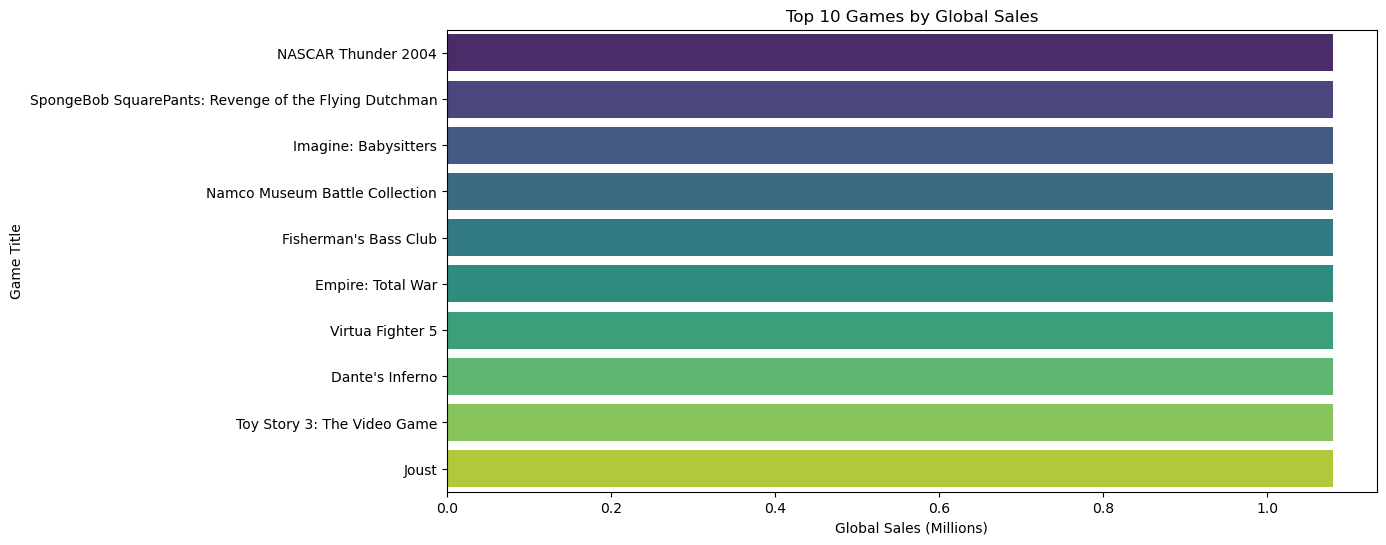

In [248]:
import matplotlib.pyplot as plt
import seaborn as sns

top_sales = merged_clean.nlargest(10, "Global_Sales")

plt.figure(figsize=(12,6))
sns.barplot(x="Global_Sales", y="Game_Title", data=top_sales, palette="viridis")
plt.xlabel("Global Sales (Millions)")
plt.ylabel("Game Title")
plt.title("Top 10 Games by Global Sales")
plt.show()

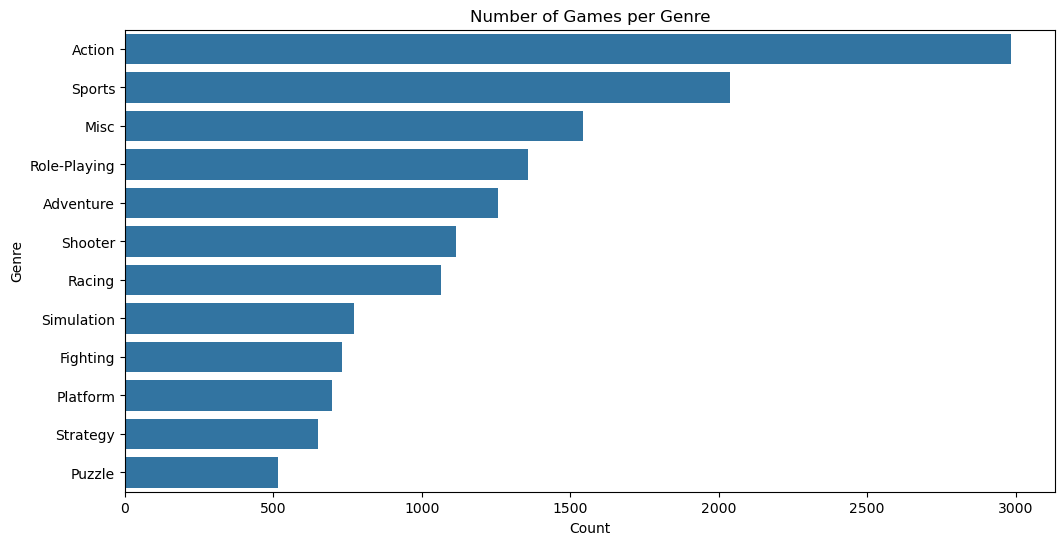

In [249]:
plt.figure(figsize=(12,6))
sns.countplot(y="Genre", data=merged_clean, order=merged_clean['Genre'].value_counts().index)
plt.title("Number of Games per Genre")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

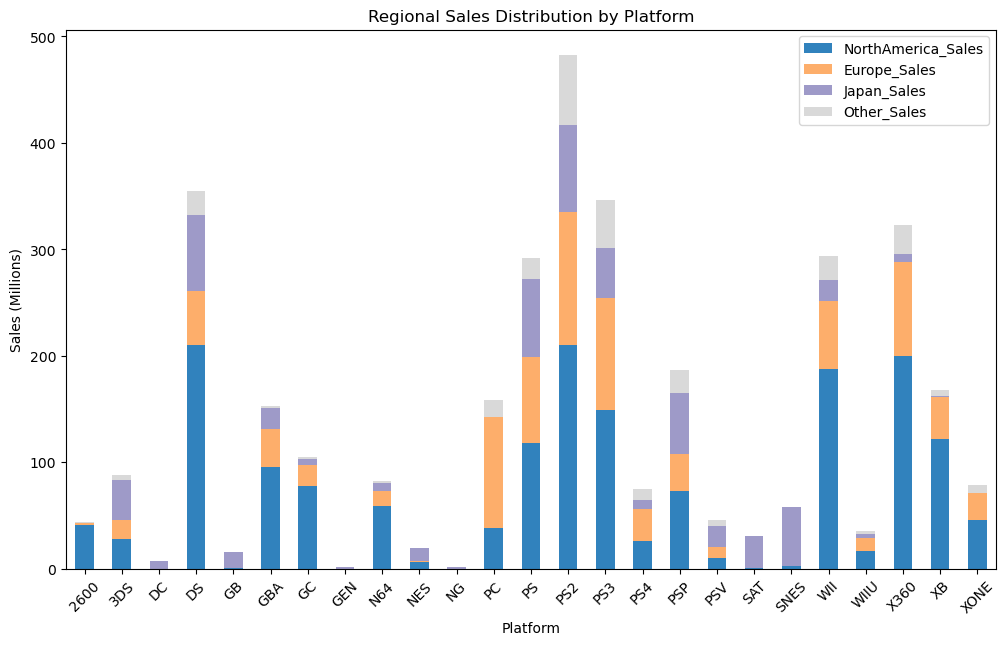

In [252]:
region_sales = merged_clean.groupby('Platform')[['NorthAmerica_Sales','Europe_Sales','Japan_Sales','Other_Sales']].sum()

region_sales.plot(kind='bar', stacked=True, figsize=(12,7), colormap='tab20c')
plt.title("Regional Sales Distribution by Platform")
plt.ylabel("Sales (Millions)")
plt.xticks(rotation=45)
plt.show()

C:\Users\Crono\AppData\Local\Temp\ipykernel_28940\1965195184.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_publishers.values, y=top_publishers.index, palette='magma')


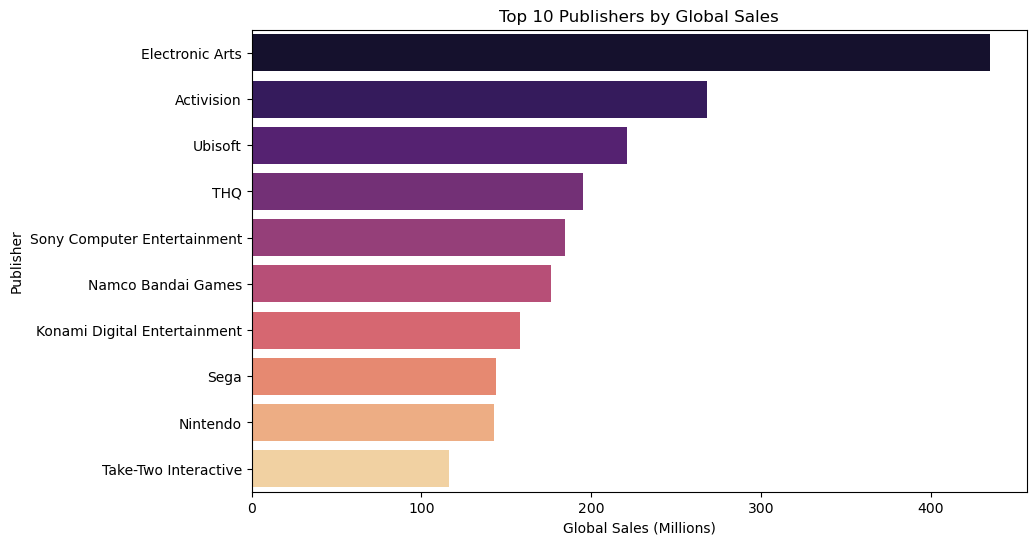

In [253]:
top_publishers = merged_clean.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_publishers.values, y=top_publishers.index, palette='magma')
plt.title("Top 10 Publishers by Global Sales")
plt.xlabel("Global Sales (Millions)")
plt.show()

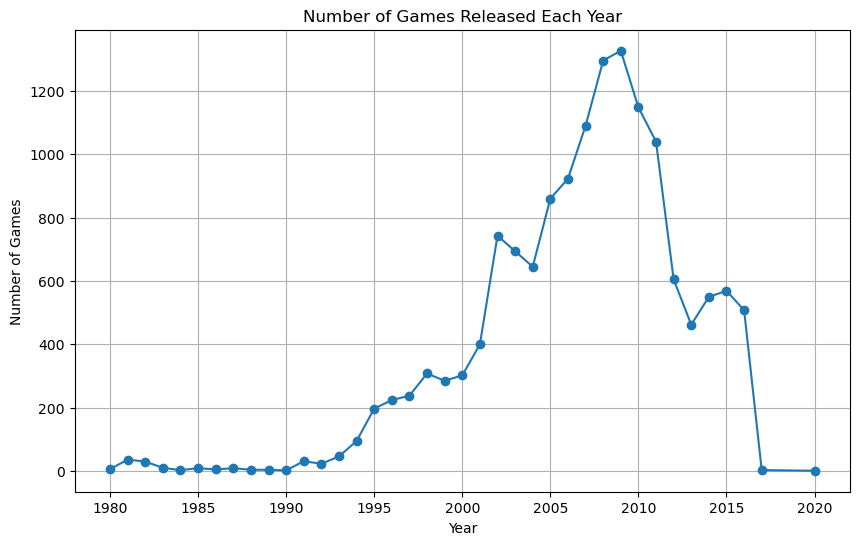

In [255]:
plt.figure(figsize=(10,6))
merged_clean.groupby('Year')['Game_Title'].count().plot(marker='o')
plt.title("Number of Games Released Each Year")
plt.xlabel("Year")
plt.ylabel("Number of Games")
plt.grid(True)
plt.show()

During this project, the merged video game sales dataset had to overgo several transformations to ensure it was clean, consistent, and analyzable. Missing values in numeric columns, such as sales figures, categorical data like platform, publisher, or genre.

In regards to the legal and regulatory guidelines, while there are no strict regulations governing historical sales data for video games, general data protection principles, such as not using personal information, were held in high standards. The primary risks associated with these transformations include potential misrepresentation of sales patterns--imputing zeros for missing sales might underestimate market trends--and loss of information when aggregating platforms or publishers. Assumptions made during cleaning include interpreting missing sales as zero, treating NaN platforms or stores as empty lists, and standardizing multi-platform indicators without context.

The data was sourced from publicly available video game sales databases and cross-referenced with verified industry sources for credibility. All acquisition was ethical, as no private or sensitive user data was involved.

To mitigate ethical implications, transparency about assumptions and transformations is essential. Documenting each cleaning step ensures reproducibility, and sensitivity analyses can be performed to understand how imputations affect results. By combining careful cleaning with responsible reporting, the dataset can be used reliably for insights without misleading interpretations or misrepresenting market dynamics.